<a href="https://colab.research.google.com/github/marcomunozq-miaad-uacj/Programacion1Semestre/blob/Matematicas1Sem/Aplicaciones_de_conceptos_estad%C3%ADsticos_en_conjunto_de_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Práctica:** Aplicaciones de conceptos estadísticos en conjunto de datos

#### **Alumno:** Marco Antonio Muñoz Quiroz

#### **Matricula:** 261540

# 1. Operaciones Basicas

**Instrucciones:**
1. Crea un array de 10 elementos con valores entre 1 y 10
2. Calcula la media, mediana, y desviaci´on est´andar de los valores.
3. Multiplica cada valor por 2.

In [82]:
import numpy as np
# Cargamos librerias

# Primero, genero un arreglo con los numeros del 1 al 10.
arr = np.arange(1, 11)

# Ahora, calculo tres medidas que me ayudan a entender el arreglo:
# - Media: el promedio de los valores.
# - Mediana: el valor central al ordenar los datos.
# - Desviacion estandar (poblacional): que tanto se dispersan los datos respecto a la media.
media = arr.mean()
mediana = np.median(arr)
desv_estandar = arr.std(ddof=0)  # uso ddof=0 porque quiero la desviacion estandar poblacional

# Despues, multiplico cada elemento por 2
arr_x2 = arr * 2

# Imprimo todo
print("=== RESULTADOS ===")
print(f"Array original: {arr}")
print(f"Media: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Desviacion estandar (poblacional): {desv_estandar:.4f}")
print(f"Array multiplicado por 2: {arr_x2}")

=== RESULTADOS ===
Array original: [ 1  2  3  4  5  6  7  8  9 10]
Media: 5.50
Mediana: 5.50
Desviacion estandar (poblacional): 2.8723
Array multiplicado por 2: [ 2  4  6  8 10 12 14 16 18 20]


# 2. Operaciones con DataFrames Objetivo: Crear y manipular un DataFrame.

**Instrucciones:**

1. Crea un DataFrame con 3 columnas (A, B, C) y 5 filas con numeros aleatorios enteros.
2. Renombra las columnas a Col1, Col2, Col3.
3. A˜nade una nueva columna que sea la suma de las columnas Col1 y Col2.
4. Elimina todas las filas donde el valor de Col3 sea menor que 10.

In [83]:
# Importamos pandas para trabajar con DataFrames y numpy para generar numeros aleatorios
import pandas as pd
import numpy as np

# 1) Creo un DataFrame con 3 columnas y 5 filas de numeros enteros aleatorios entre 1 y 10
# Uso randint porque me permite generar estos numeros facilmente
df = pd.DataFrame(
    np.random.randint(1, 11, size=(5, 3)),
    columns=["A", "B", "C"]
)

print("DataFrame original:")
print(df)

# 2) Renombro las columnas para que tengan nombres mas descriptivos
df.columns = ["Col1", "Col2", "Col3"]

print("\nDataFrame con columnas renombradas:")
print(df)

# 3) Agrego una nueva columna que es la suma de Col1 y Col2
df["Suma_Col1_Col2"] = df["Col1"] + df["Col2"]

print("\nDataFrame despues de agregar la nueva columna:")
print(df)

# 4) Elimino las filas donde Col3 es menor que 10
df = df[df["Col3"] >= 10]

print("\nDataFrame final (filas donde Col3 es menor que 10 fueron eliminadas):")
print(df)


DataFrame original:
    A   B  C
0   9   5  1
1   3  10  8
2   6   8  9
3   4   1  1
4  10   4  7

DataFrame con columnas renombradas:
   Col1  Col2  Col3
0     9     5     1
1     3    10     8
2     6     8     9
3     4     1     1
4    10     4     7

DataFrame despues de agregar la nueva columna:
   Col1  Col2  Col3  Suma_Col1_Col2
0     9     5     1              14
1     3    10     8              13
2     6     8     9              14
3     4     1     1               5
4    10     4     7              14

DataFrame final (filas donde Col3 es menor que 10 fueron eliminadas):
Empty DataFrame
Columns: [Col1, Col2, Col3, Suma_Col1_Col2]
Index: []


# 3. Estadıstica descriptiva

**Instrucciones:**
1. Crea un DataFrame con 100 valores aleatorios entre 0 y 50.
2. Calcula la media, mediana y moda de los valores.
3. Encuentra el valor minimo y el valor maximo del DataFrame.

In [84]:
# Importo las librerias necesarias para generar datos y hacer estadistica
import pandas as pd
import numpy as np
from scipy import stats

# 1) Genero un DataFrame con 100 valores aleatorios entre 0 y 50
# Uso randint para asegurar que los valores sean enteros dentro del rango indicado
df = pd.DataFrame({
    "Valores": np.random.randint(0, 51, size=100)
})

print("Primeros datos generados:")
print(df.head())

# 2) Calculo medidas estadisticas basicas para entender la distribucion de los datos
media = df["Valores"].mean()     # promedio de los datos
mediana = df["Valores"].median() # valor central
moda = stats.mode(df["Valores"], keepdims=True).mode[0]  # valor que mas se repite

print("\nMedidas estadisticas:")
print(f"Media: {media}")
print(f"Mediana: {mediana}")
print(f"Moda: {moda}")

# 3) Encuentro el valor minimo y el valor maximo
minimo = df["Valores"].min()
maximo = df["Valores"].max()

print("\nRango de valores:")
print(f"Valor minimo: {minimo}")
print(f"Valor maximo: {maximo}")


Primeros datos generados:
   Valores
0        1
1        2
2       48
3       36
4       48

Medidas estadisticas:
Media: 23.51
Mediana: 24.0
Moda: 1

Rango de valores:
Valor minimo: 0
Valor maximo: 49


# 4.Analisis de series temporales

**Instrucciones:**
1. Crea un DataFrame con una columna de fechas (usa pd.date_range() para enerar las fechas).
2. Genera 100 valores aleatorios asociados a estas fechas.
3. Calcula la media movil de los valores con una ventana de 5 dıas.

In [85]:
# Importo librerias usadas
import pandas as pd
import numpy as np

# 1) Creo un rango de fechas diario. Elijo un inicio fijo para que sea reproducible.
fechas = pd.date_range(start="2025-01-01", periods=100, freq="D")

# 2) Genero 100 valores aleatorios asociados a estas fechas.
#    Uso una semilla para que los resultados sean consistentes si vuelvo a ejecutar.
np.random.seed(42)
valores = np.random.randn(100) * 10 + 50  # centro los datos alrededor de 50

# Armo el DataFrame y pongo la fecha como indice porque facilita operaciones de tiempo
df = pd.DataFrame({"Fecha": fechas, "Valor": valores}).set_index("Fecha")

print("Primeras filas del DataFrame:")
print(df.head())

# 3) Calculo la media movil con una ventana de 5 dias.
#    Uso rolling(5).mean() para suavizar la serie y ver tendencias de corto plazo.
df["Media_movil_5d"] = df["Valor"].rolling(window=5).mean()

print("\nUltimas filas con la media movil de 5 dias:")
print(df.tail())

# Si quiero ver solo las columnas de interes, puedo imprimir asi:
print("\nSolo Valor y Media_movil_5d:")
print(df[["Valor", "Media_movil_5d"]].head(20))


Primeras filas del DataFrame:
                Valor
Fecha                
2025-01-01  54.967142
2025-01-02  48.617357
2025-01-03  56.476885
2025-01-04  65.230299
2025-01-05  47.658466

Ultimas filas con la media movil de 5 dias:
                Valor  Media_movil_5d
Fecha                                
2025-04-06  35.364851       46.166613
2025-04-07  52.961203       44.821564
2025-04-08  52.610553       46.747781
2025-04-09  50.051135       47.413332
2025-04-10  47.654129       47.728374

Solo Valor y Media_movil_5d:
                Valor  Media_movil_5d
Fecha                                
2025-01-01  54.967142             NaN
2025-01-02  48.617357             NaN
2025-01-03  56.476885             NaN
2025-01-04  65.230299             NaN
2025-01-05  47.658466       54.590030
2025-01-06  47.658630       53.128328
2025-01-07  65.792128       56.563282
2025-01-08  57.674347       56.802774
2025-01-09  45.305256       52.817766
2025-01-10  55.425600       54.371192
2025-01-11  45.3658

# 5.Grafico de lineas

**Instrucciones:**
1. Crea una serie de datos aleatorios (entre 0 y 100) de tamaño 50.
2. Usa Matplotlib para graficar los datos en un grafico de lıneas.
3. Añade tıtulo, etiquetas a los ejes y una leyenda.
4. Cambia el color de la lınea a rojo y usa un estilo de lınea punteado.

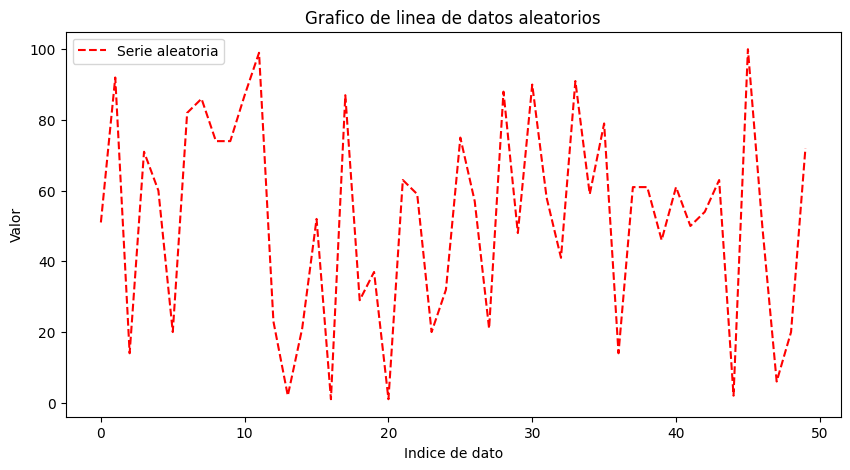

In [86]:
# Importo las librerias necesarias para generar datos y graficar
import numpy as np
import matplotlib.pyplot as plt

# Genero una serie de 50 datos aleatorios entre 0 y 100
np.random.seed(42)  # uso semilla para tener resultados reproducibles
datos = np.random.randint(0, 101, size=50)

# Creo el grafico de lineas con estilo punteado y color rojo
plt.figure(figsize=(10, 5))
plt.plot(datos, color="red", linestyle="--", label="Serie aleatoria")

# Agrego titulo y etiquetas
plt.title("Grafico de linea de datos aleatorios")
plt.xlabel("Indice de dato")
plt.ylabel("Valor")

# Agrego la leyenda para identificar la serie
plt.legend()

# Muestro el grafico
plt.show()


# 6.Grafico de Barras

**Instrucciones:**
1. Cargar el dataset "tips" de Seaborn.
2. Agrupar los valores de la columna total_bill por dia.
3. Crear un grafico de barras para visualizar la suma de total_bill por cada dia.
4. Anadir etiquetas a los ejes y un titulo.

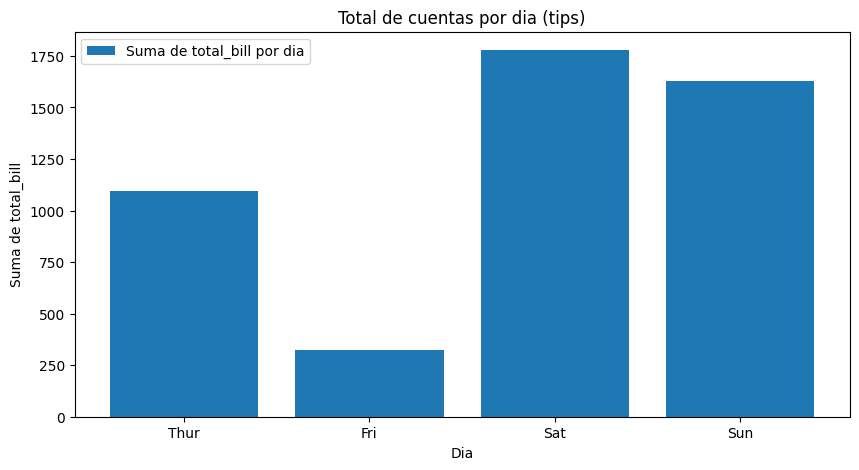

In [87]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargo el dataset tips de seaborn
tips = sns.load_dataset("tips")

# Agrupo por dia y sumo el total de las cuentas
orden_dias = ["Thur", "Fri", "Sat", "Sun"]
resumen = (
    tips.groupby("day", as_index=False, observed=True)["total_bill"]
        .sum()
        .assign(day=lambda d: pd.Categorical(d["day"], categories=orden_dias, ordered=True))
        .sort_values("day")
)

# Creo el grafico de barras con los totales por dia
plt.figure(figsize=(10, 5))
plt.bar(resumen["day"], resumen["total_bill"], label="Suma de total_bill por dia")

# Agrego titulo y etiquetas
plt.title("Total de cuentas por dia (tips)")
plt.xlabel("Dia")
plt.ylabel("Suma de total_bill")
plt.legend()

plt.show()


# 7.Histograma

**Instrucciones:**
1. Generar 1000 numeros aleatorios con distribucion normal (media=0, desviacion estandar=1).
2. Crear un histograma para visualizar la distribucion.
3. Ajustar el numero de bins para que la visualizacion sea clara.

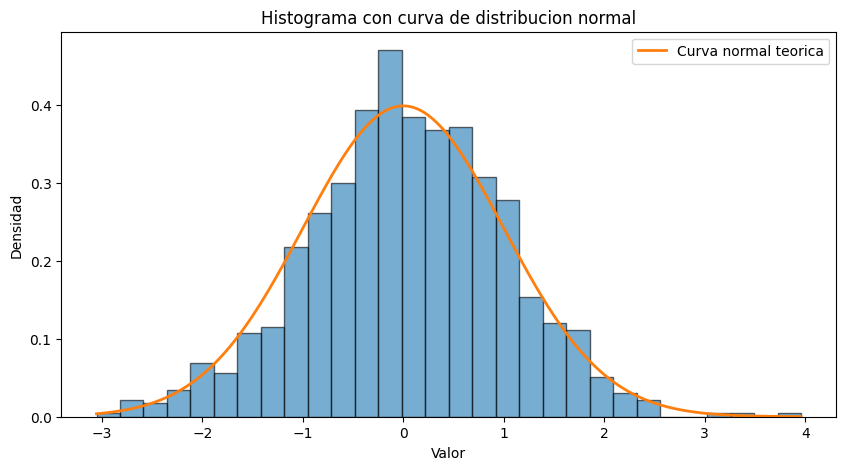

In [88]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Genero los datos aleatorios con distribucion normal
np.random.seed(1)
datos = np.random.normal(loc=0, scale=1, size=1000)

# Creo el histograma
plt.figure(figsize=(10, 5))
cuentas, bins, patches = plt.hist(datos, bins=30, density=True, edgecolor="black", alpha=0.6)

# Genero la curva teorica de la distribucion normal
# Uso el punto medio de cada bin para graficar la densidad
x = np.linspace(min(datos), max(datos), 1000)
curva_normal = norm.pdf(x, loc=0, scale=1)

# Grafico la linea continua
plt.plot(x, curva_normal, linewidth=2, label="Curva normal teorica")

# Agrego informacion
plt.title("Histograma con curva de distribucion normal")
plt.xlabel("Valor")
plt.ylabel("Densidad")
plt.legend()

plt.show()


# 8. Scatter Plot

**Instrucciones:**
1. Cargar el dataset iris de Seaborn.
2. Crear un grafico de dispersion entre sepal_width y sepal_length.
3. Colorear los puntos segun la especie para observar diferencias visuales.

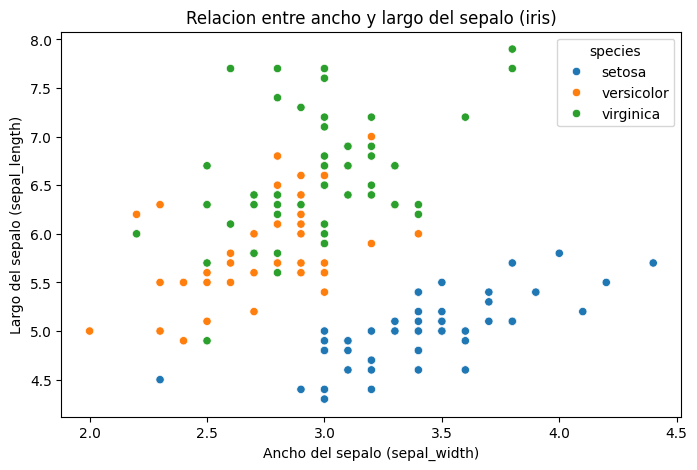

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

# Cargo el dataset iris
iris = sns.load_dataset("iris")

# Creo el grafico de dispersion usando colores por especie
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=iris,
    x="sepal_width",
    y="sepal_length",
    hue="species"  # esto asigna un color diferente a cada especie
)

# Agrego titulo y etiquetas
plt.title("Relacion entre ancho y largo del sepalo (iris)")
plt.xlabel("Ancho del sepalo (sepal_width)")
plt.ylabel("Largo del sepalo (sepal_length)")

plt.show()

# 9. Heatmap

**Instrucciones:**
1. Usar el dataset iris de Seaborn.
2. Calcular la matriz de correlacion de las variables numericas.
3. Crear un heatmap para visualizar la matriz de correlacion.

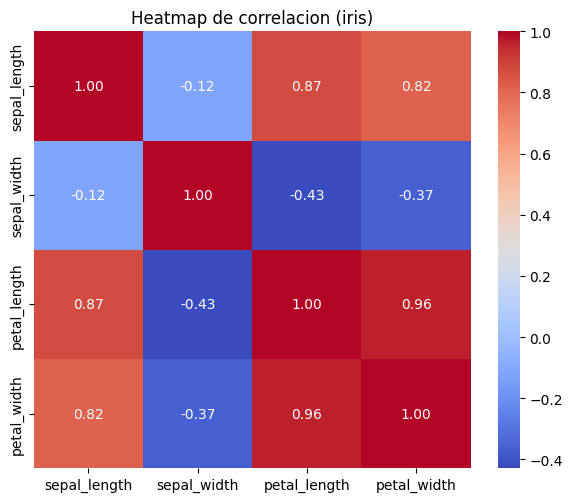

In [90]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Cargo el dataset iris
iris = sns.load_dataset("iris")

# Selecciono solo columnas numericas y calculo la matriz de correlacion
corr = iris.select_dtypes(include="number").corr()

# Muestro el heatmap con anotaciones para ver los coeficientes
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)

# Agrego un titulo para contextualizar
plt.title("Heatmap de correlacion (iris)")

plt.tight_layout()
plt.show()

# 10. Grafico de Linea con Media Movil

**Instrucciones:**
1. Generar una serie temporal diaria de 100 dias con valores aleatorios.
2. Calcular la media movil de los ultimos 10 dias.
3. Graficar la serie original y la media movil con colores distintos.

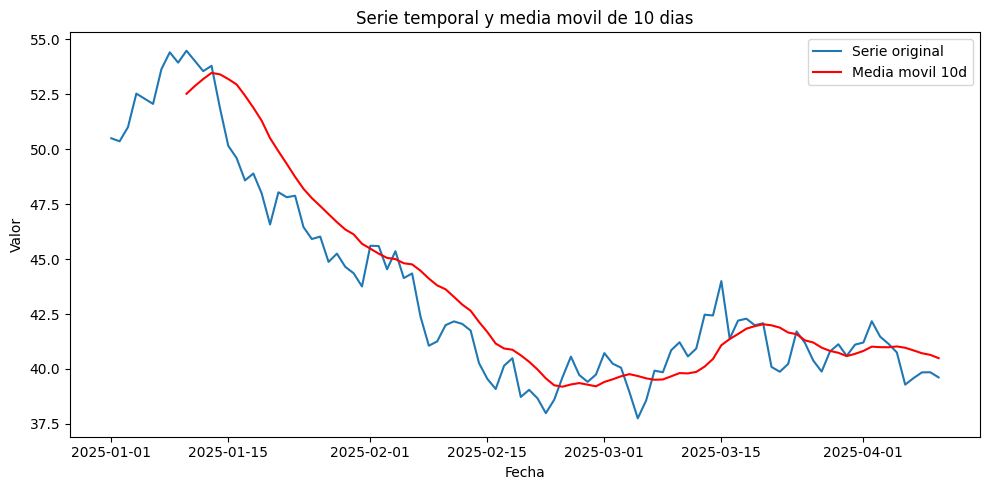

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Genero fechas diarias y valores aleatorios
np.random.seed(42)  # dejo semilla para reproducibilidad
fechas = pd.date_range(start="2025-01-01", periods=100, freq="D")
valores = np.random.randn(100).cumsum() + 50  # hago una serie con tendencia leve

# Armo el DataFrame y calculo la media movil de 10 dias
df = pd.DataFrame({"Valor": valores}, index=fechas)
df["MediaMovil_10"] = df["Valor"].rolling(window=10).mean()

# Grafico la serie original y la media movil
plt.figure(figsize=(10, 5))
plt.plot(df.index, df["Valor"], label="Serie original")        # color por defecto
plt.plot(df.index, df["MediaMovil_10"], label="Media movil 10d", color="red")  # color distinto

# Etiquetas y titulo
plt.title("Serie temporal y media movil de 10 dias")
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.legend()
plt.tight_layout()
plt.show()

# 11. Datos Temporales con Analisis Estadıstico

**Instrucciones:**
1. Generar una serie temporal de 200 dias con valores aleatorios.
2. Calcular la media y la desviacion estandar de la serie.
3. Visualizar la serie junto con las bandas de media + desviacion y media - desviacion.

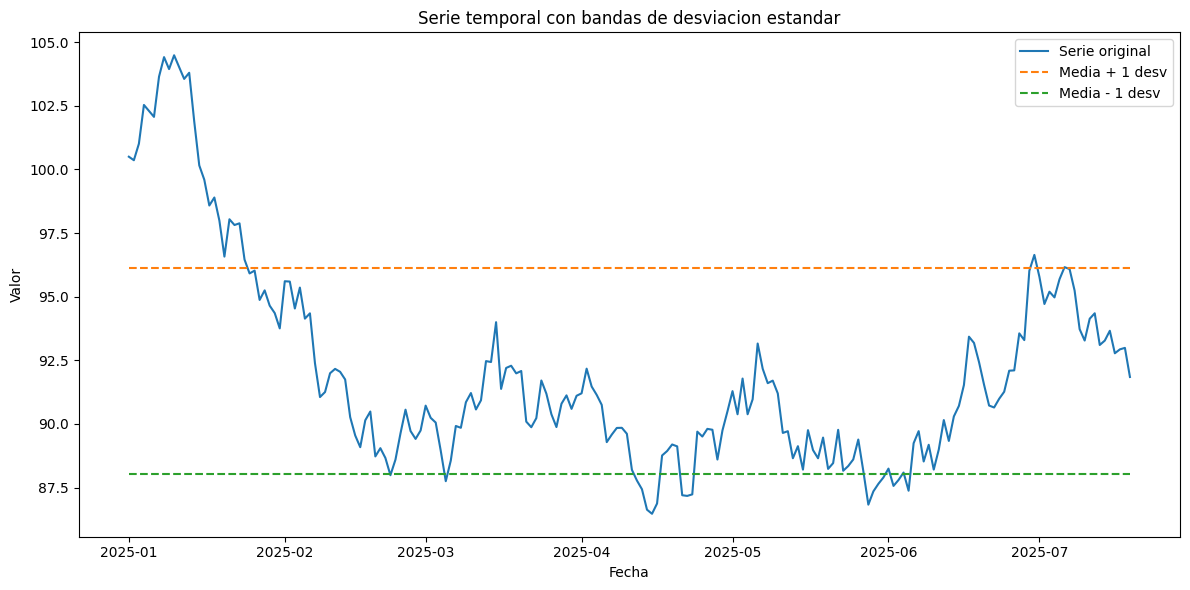

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Genero la serie temporal con valores que simulan un comportamiento realista mediante suma acumulada
np.random.seed(42)
fechas = pd.date_range(start="2025-01-01", periods=200, freq="D")
valores = np.random.randn(200).cumsum() + 100  # empiezo alrededor de 100 para hacerlo mas interpretable

# Creo el DataFrame
df = pd.DataFrame({"Valor": valores}, index=fechas)

# Calculo la media y la desviacion estandar
media = df["Valor"].mean()
desv = df["Valor"].std()

# Creo columnas para las bandas de desviacion
df["Banda_superior"] = media + desv
df["Banda_inferior"] = media - desv

# Grafico la serie original y las bandas
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["Valor"], label="Serie original")
plt.plot(df.index, df["Banda_superior"], linestyle="--", label="Media + 1 desv")
plt.plot(df.index, df["Banda_inferior"], linestyle="--", label="Media - 1 desv")

# Agrego etiquetas y titulo
plt.title("Serie temporal con bandas de desviacion estandar")
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.legend()
plt.tight_layout()
plt.show()